# The Visual Storyteller — Inference


## 0. Setup

In [1]:
import os
import random
import re

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision.models import ResNet50_Weights
from PIL import Image
import matplotlib.pyplot as plt

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cpu


In [2]:
import os
import random
import re

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision.models import ResNet50_Weights
from PIL import Image
import matplotlib.pyplot as plt

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")


class Vocabulary:
    def __init__(self, freq_threshold):
        self.itos = {0: "<PAD>", 1: "<SOS>", 2: "<EOS>", 3: "<UNK>"}
        self.stoi = {"<PAD>": 0, "<SOS>": 1, "<EOS>": 2, "<UNK>": 3}
        self.freq_threshold = freq_threshold

    def __len__(self):
        return len(self.itos)

    @staticmethod
    def tokenizer_eng(text):
        text = text.lower().strip()
        text = re.sub(r"([.,!?;:'\"])", r" \1 ", text)
        return text.split()

    def build_vocabulary(self, sentence_list):
        frequencies = {}
        idx = 4
        for sentence in sentence_list:
            for word in self.tokenizer_eng(sentence):
                frequencies[word] = frequencies.get(word, 0) + 1
                if frequencies[word] == self.freq_threshold:
                    self.stoi[word] = idx
                    self.itos[idx] = word
                    idx += 1

    def numericalize(self, text):
        tokenized_text = self.tokenizer_eng(text)
        return [self.stoi.get(token, self.stoi["<UNK>"]) for token in tokenized_text]

Using device: cpu


In [3]:
class EncoderCNN(nn.Module):
    def __init__(self, encoded_image_size=5, fine_tune=False):
        super(EncoderCNN, self).__init__()
        self.encoded_image_size = encoded_image_size

        resnet = models.resnet50(weights=ResNet50_Weights.DEFAULT)
        modules = list(resnet.children())[:-2]
        self.resnet = nn.Sequential(*modules)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((encoded_image_size, encoded_image_size))
        self.set_fine_tune(fine_tune)

    def forward(self, images):
        features = self.resnet(images)
        features = self.adaptive_pool(features)
        features = features.permute(0, 2, 3, 1)
        features = features.view(features.size(0), -1, features.size(-1))
        return features

    def set_fine_tune(self, fine_tune=False, unfreeze_from_block=7):
        for p in self.resnet.parameters():
            p.requires_grad = False
        if fine_tune:
            children = list(self.resnet.children())
            for block in children[unfreeze_from_block:]:
                for p in block.parameters():
                    p.requires_grad = True


class Attention(nn.Module):
    def __init__(self, encoder_dim, decoder_dim, attention_dim):
        super(Attention, self).__init__()
        self.attn_proj = nn.Linear(encoder_dim + decoder_dim, attention_dim)
        self.score_proj = nn.Linear(attention_dim, 1, bias=False)

    def forward(self, encoder_out, decoder_hidden):
        num_pixels = encoder_out.size(1)
        hidden_expanded = decoder_hidden.unsqueeze(1).expand(-1, num_pixels, -1)
        energy = torch.tanh(self.attn_proj(torch.cat((encoder_out, hidden_expanded), dim=2)))
        scores = self.score_proj(energy).squeeze(2)
        alpha = F.softmax(scores, dim=1)
        context = (encoder_out * alpha.unsqueeze(2)).sum(dim=1)
        return context, alpha


class DecoderRNN(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, encoder_dim=2048,
                 attention_dim=256, dropout=0.5, embed_dropout=0.2):
        super(DecoderRNN, self).__init__()
        self.hidden_size = hidden_size
        self.vocab_size = vocab_size
        self.encoder_dim = encoder_dim

        self.attention = Attention(encoder_dim, hidden_size, attention_dim)
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.embed_dropout = nn.Dropout(embed_dropout)
        self.lstm_cell = nn.LSTMCell(embed_size + encoder_dim, hidden_size, bias=True)
        self.init_h = nn.Linear(encoder_dim, hidden_size)
        self.init_c = nn.Linear(encoder_dim, hidden_size)
        self.layer_norm = nn.LayerNorm(hidden_size)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, vocab_size)

        self._init_weights()

    def _init_weights(self):
        nn.init.uniform_(self.embed.weight, -0.1, 0.1)
        nn.init.uniform_(self.fc.weight, -0.1, 0.1)
        nn.init.zeros_(self.fc.bias)

    def init_hidden_state(self, encoder_out):
        mean_encoder_out = encoder_out.mean(dim=1)
        h = self.init_h(mean_encoder_out)
        c = self.init_c(mean_encoder_out)
        return h, c

    def forward(self, encoder_out, captions, teacher_forcing_ratio=1.0):
        batch_size = encoder_out.size(0)
        device = encoder_out.device
        num_steps = captions.size(1) - 1
        num_pixels = encoder_out.size(1)

        h, c = self.init_hidden_state(encoder_out)
        predictions = torch.zeros(batch_size, num_steps, self.vocab_size, device=device)
        alphas = torch.zeros(batch_size, num_steps, num_pixels, device=device)
        input_word = captions[:, 0]

        for t in range(num_steps):
            embeddings = self.embed_dropout(self.embed(input_word))
            context, alpha = self.attention(encoder_out, h)
            h, c = self.lstm_cell(torch.cat((embeddings, context), dim=1), (h, c))
            h_norm = self.layer_norm(h)
            preds = self.fc(self.dropout(h_norm))

            predictions[:, t, :] = preds
            alphas[:, t, :] = alpha

            use_teacher_forcing = self.training and (random.random() < teacher_forcing_ratio)
            input_word = captions[:, t + 1] if use_teacher_forcing else preds.argmax(dim=1).detach()

        return predictions, alphas


class CNNtoRNN(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, attention_dim=256,
                 encoder_dim=2048, dropout=0.5, fine_tune_encoder=False):
        super(CNNtoRNN, self).__init__()
        self.encoderCNN = EncoderCNN(fine_tune=fine_tune_encoder)
        self.decoderRNN = DecoderRNN(
            embed_size=embed_size, hidden_size=hidden_size, vocab_size=vocab_size,
            encoder_dim=encoder_dim, attention_dim=attention_dim, dropout=dropout,
        )

    def forward(self, images, captions, teacher_forcing_ratio=1.0):
        encoder_out = self.encoderCNN(images)
        predictions, alphas = self.decoderRNN(encoder_out, captions, teacher_forcing_ratio)
        return predictions, alphas

    def unfreeze_encoder(self):
        self.encoderCNN.set_fine_tune(fine_tune=True)

    @torch.no_grad()
    def caption_image(self, image, vocabulary, max_length=50, device="cuda"):
        was_training = self.training
        self.eval()
        encoder_out = self.encoderCNN(image)
        h, c = self.decoderRNN.init_hidden_state(encoder_out)
        word = torch.tensor([vocabulary.stoi["<SOS>"]], device=device)

        result_caption = []
        for _ in range(max_length):
            embeddings = self.decoderRNN.embed(word)
            context, _ = self.decoderRNN.attention(encoder_out, h)
            h, c = self.decoderRNN.lstm_cell(torch.cat((embeddings, context), dim=1), (h, c))
            h_norm = self.decoderRNN.layer_norm(h)
            preds = self.decoderRNN.fc(h_norm)
            predicted = preds.argmax(dim=1)

            token = vocabulary.itos[predicted.item()]
            if token == "<EOS>":
                break
            if token != "<SOS>":
                result_caption.append(token)
            word = predicted

        if was_training:
            if was_training:
                self.train()
        return result_caption

    @torch.no_grad()
    def beam_search_caption(self, image, vocabulary, max_length=50, beam_width=3, device="cuda"):
        was_training = self.training
        self.eval()
        encoder_out = self.encoderCNN(image)
        h0, c0 = self.decoderRNN.init_hidden_state(encoder_out)

        start_word = torch.tensor([vocabulary.stoi["<SOS>"]], device=device)
        embeddings = self.decoderRNN.embed(start_word)
        context, _ = self.decoderRNN.attention(encoder_out, h0)
        h, c = self.decoderRNN.lstm_cell(torch.cat((embeddings, context), dim=1), (h0, c0))
        h_norm = self.decoderRNN.layer_norm(h)
        log_probs = F.log_softmax(self.decoderRNN.fc(h_norm), dim=1)
        top_probs, top_idx = log_probs.topk(beam_width, dim=1)

        beams = []
        for i in range(beam_width):
            word_idx = top_idx[0][i]
            score = top_probs[0][i].item()
            beams.append((score, word_idx.unsqueeze(0), h, c, [word_idx.item()]))

        for _ in range(max_length - 1):
            candidates = []
            for score, last_word, h_i, c_i, seq in beams:
                if vocabulary.itos[seq[-1]] == "<EOS>":
                    candidates.append((score, last_word, h_i, c_i, seq))
                    continue

                embeddings = self.decoderRNN.embed(last_word)
                context, _ = self.decoderRNN.attention(encoder_out, h_i)
                h_new, c_new = self.decoderRNN.lstm_cell(
                    torch.cat((embeddings, context), dim=1), (h_i, c_i)
                )
                h_norm = self.decoderRNN.layer_norm(h_new)
                log_probs = F.log_softmax(self.decoderRNN.fc(h_norm), dim=1)
                top_probs, top_idx = log_probs.topk(beam_width, dim=1)

                for i in range(beam_width):
                    new_word_idx = top_idx[0][i]
                    new_score = score + top_probs[0][i].item()
                    new_seq = seq + [new_word_idx.item()]
                    candidates.append((new_score, new_word_idx.unsqueeze(0), h_new, c_new, new_seq))

            beams = sorted(candidates, key=lambda x: x[0], reverse=True)[:beam_width]
            if all(vocabulary.itos[b[4][-1]] == "<EOS>" for b in beams):
                break

        best_seq = beams[0][4]
        result_caption = [
            vocabulary.itos[idx] for idx in best_seq
            if vocabulary.itos[idx] not in ("<EOS>", "<SOS>")
        ]
        self.train()
        return result_caption


In [4]:
class CaptionModel:
    def __init__(self, model, vocab, transform, device, use_beam_search=True, beam_width=3):
        self.model = model
        self.vocab = vocab
        self.transform = transform
        self.device = device
        self.use_beam_search = use_beam_search
        self.beam_width = beam_width

    @classmethod
    def from_checkpoint(cls, checkpoint_path, device=None, use_beam_search=True, beam_width=3):
        # Prefer CUDA when available, but inference can always run on CPU too.
        device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
        checkpoint_path = str(checkpoint_path)

        print(f"=> Loading checkpoint: {checkpoint_path}")
        try:
            checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
        except TypeError:
            checkpoint = torch.load(checkpoint_path, map_location=device)
        except RuntimeError as e:
            # Some CUDA checkpoints fail on small GPUs; CPU inference is slower but safer.
            print(f"CUDA load failed ({e}). Retrying on CPU...")
            device = torch.device("cpu")
            checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)

        config = checkpoint["config"]
        vocab = checkpoint["vocab"]

        print(f"   Experiment: {config.get('experiment_name', 'unknown')}")
        print(f"   Epoch: {checkpoint.get('epoch', 'unknown')}")
        print(f"   Vocab size: {len(vocab)}")
        print(f"   Inference device: {device}")

        model = CNNtoRNN(
            embed_size=config["embed_size"],
            hidden_size=config["hidden_size"],
            vocab_size=len(vocab),
            attention_dim=config.get("attention_dim", 256),
            dropout=config.get("dropout", 0.5),
        ).to(device)

        model.load_state_dict(checkpoint["state_dict"], strict=True)
        model.eval()

        transform = transforms.Compose([
            transforms.Resize(256),
            transforms.CenterCrop(224),
            transforms.ToTensor(),
            transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
        ])

        return cls(model, vocab, transform, device, use_beam_search, beam_width)


In [5]:
def generate_caption(image_path: str, model: "CaptionModel") -> str:
    """
    Takes a path to an image and returns a generated caption string.

    `model` is a CaptionModel (see CaptionModel.from_checkpoint), which
    bundles the trained network, vocab, transform, and device.
    """
    image = Image.open(image_path).convert("RGB")
    image_tensor = model.transform(image).unsqueeze(0).to(model.device)

    if model.use_beam_search:
        tokens = model.model.beam_search_caption(
            image_tensor, model.vocab,
            beam_width=model.beam_width, device=model.device
        )
    else:
        tokens = model.model.caption_image(
            image_tensor, model.vocab, device=model.device
        )

    return " ".join(tokens)


def generate_captions_for_dir(image_dir, model, extensions=(".jpg", ".jpeg", ".png")):
    """
    Runs generate_caption over every image in a directory.
    Returns {filename: caption}. Useful for building the
    "successful vs. failure case" comparison below.
    """
    results = {}
    for fname in sorted(os.listdir(image_dir)):
        if fname.lower().endswith(extensions):
            path = os.path.join(image_dir, fname)
            results[fname] = generate_caption(path, model)
    return results

In [6]:
def get_attention_map(model, image_tensor, vocab, device, max_length=50):
    """
    Returns (words, alphas) where alphas is a list of (S, S) attention
    grids, one per generated word (S = encoder's spatial grid size).
    """
    was_training = model.training
    model.eval()
    with torch.no_grad():
        encoder_out = model.encoderCNN(image_tensor)
        num_pixels = encoder_out.size(1)
        grid_size = int(num_pixels ** 0.5)

        h, c = model.decoderRNN.init_hidden_state(encoder_out)
        word = torch.tensor([vocab.stoi["<SOS>"]], device=device)

        words, alphas = [], []
        for _ in range(max_length):
            embeddings = model.decoderRNN.embed(word)
            context, alpha = model.decoderRNN.attention(encoder_out, h)
            h, c = model.decoderRNN.lstm_cell(torch.cat((embeddings, context), dim=1), (h, c))
            h_norm = model.decoderRNN.layer_norm(h)
            preds = model.decoderRNN.fc(h_norm)
            predicted = preds.argmax(dim=1)

            token = vocab.itos[predicted.item()]
            if token == "<EOS>":
                break
            if token != "<SOS>":
                words.append(token)
                alphas.append(alpha.view(grid_size, grid_size).cpu())

            word = predicted

    if was_training:
        model.train()
    return words, alphas


def plot_attention(image_path, words, alphas, max_words=12):
    """Plots the image once per generated word with the attention grid overlaid."""
    if len(words) == 0 or len(alphas) == 0:
        print("No attention map to plot because the generated caption is empty.")
        return

    image = Image.open(image_path).convert("RGB").resize((224, 224))
    n = min(len(words), len(alphas), max_words)
    cols = 4
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
    if rows == 1 and cols == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i in range(n):
        ax = axes[i]
        ax.imshow(image)
        alpha_img = alphas[i].numpy()
        ax.imshow(alpha_img, alpha=0.6, cmap="jet", extent=(0, 224, 224, 0))
        ax.set_title(words[i])
        ax.axis("off")

    for i in range(n, len(axes)):
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()


In [7]:
import os
import random
import shutil
from pathlib import Path

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
SOURCE_IMAGE_DIRS = [Path("content/Images"), Path("caption_data/Images"), Path("Images")]
TEST_IMAGE_DIR = Path("content/test_images")
TEST_IMAGE_DIR.mkdir(parents=True, exist_ok=True)

source_dir = next((p for p in SOURCE_IMAGE_DIRS if p.exists()), None)
if source_dir is None:
    print("No image source directory found. Checked: content/Images, caption_data/Images, Images")
else:
    image_files = sorted([p for p in source_dir.iterdir() if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS])
    random.seed(42)
    selected = random.sample(image_files, min(800, len(image_files)))

    for image_path in selected:
        destination = TEST_IMAGE_DIR / image_path.name
        if not destination.exists():
            shutil.copy2(image_path, destination)

    print(f"Prepared {len(selected)} images in {TEST_IMAGE_DIR}")
    print(f"Source directory: {source_dir}")


Prepared 800 images in content\test_images
Source directory: caption_data\Images


In [8]:
from pathlib import Path

# Auto-detect checkpoint instead of relying on one hard-coded timestamped folder.
checkpoint_candidates = sorted(Path("experiments").glob("**/best_model.pth.tar"), key=lambda p: p.stat().st_mtime, reverse=True)

if checkpoint_candidates:
    CHECKPOINT_FILE = str(checkpoint_candidates[0])
else:
    CHECKPOINT_FILE = "experiments/2026-07-02_13-25-57_ResNet50_Attn_LSTM_fixed/weights/best_model.pth.tar"

TEST_IMAGE_DIR = "content/test_images"

caption_model = None
if os.path.exists(CHECKPOINT_FILE):
    caption_model = CaptionModel.from_checkpoint(CHECKPOINT_FILE)
else:
    print(f"Checkpoint not found at {CHECKPOINT_FILE}. Train the model first or update CHECKPOINT_FILE.")


=> Loading checkpoint: experiments\2026-07-02_13-25-57_ResNet50_Attn_LSTM_fixed\weights\best_model.pth.tar
   Experiment: ResNet50_Attn_LSTM_fixed
   Epoch: 25
   Vocab size: 2663
   Inference device: cpu


In [9]:
# Generate only a small preview by default, so the notebook does not look stuck.
# Increase MAX_PREVIEW_IMAGES if you want more examples.
MAX_PREVIEW_IMAGES = 10

if caption_model is not None and os.path.isdir(TEST_IMAGE_DIR):
    preview_files = sorted(
        f for f in os.listdir(TEST_IMAGE_DIR)
        if Path(f).suffix.lower() in IMAGE_EXTENSIONS
    )[:MAX_PREVIEW_IMAGES]

    all_captions = {}
    for fname in preview_files:
        path = os.path.join(TEST_IMAGE_DIR, fname)
        cap = generate_caption(path, caption_model)
        all_captions[fname] = cap
        print(f"{fname}: {cap}")
else:
    print(f"Test image directory not found at {TEST_IMAGE_DIR} -- update the path and rerun.")


1003163366_44323f5815.jpg: a man lays on a bench bench .
1007129816_e794419615.jpg: a man with a <UNK> hat is wearing a hat .
1019077836_6fc9b15408.jpg: a brown dog is running on a lawn .
1022454428_b6b660a67b.jpg: a couple and a woman sitting on a stroller .
103195344_5d2dc613a3.jpg: a man stands on a <UNK> at a <UNK> .
1032460886_4a598ed535.jpg: people walking on a city street .
1072153132_53d2bb1b60.jpg: a black and white dog jumping to catch a ball .
1075881101_d55c46bece.jpg: a boy is covered in bubbles .
1082379191_ec1e53f996.jpg: a man and a woman sitting on a dock .
109260216_85b0be5378.jpg: a person climbs a rock .


Image: content/test_images\1003163366_44323f5815.jpg
Caption: a man lays on a bench bench .


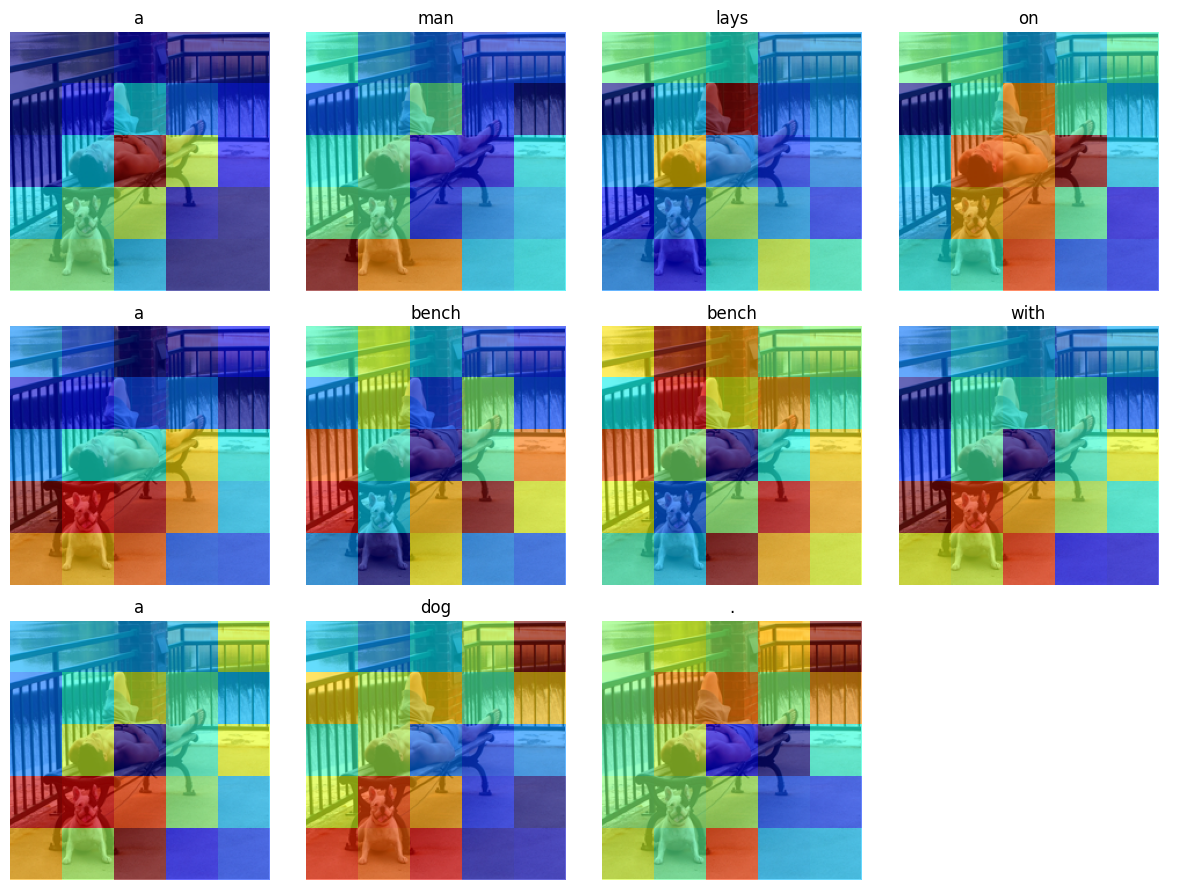

In [10]:
if caption_model is not None:
    # Do not require a file named test_image.jpg. Use it if present; otherwise use the first prepared test image.
    IMAGE_FILE = "test_image.jpg"
    if not os.path.exists(IMAGE_FILE) and os.path.isdir(TEST_IMAGE_DIR):
        test_images = sorted(
            os.path.join(TEST_IMAGE_DIR, f)
            for f in os.listdir(TEST_IMAGE_DIR)
            if Path(f).suffix.lower() in IMAGE_EXTENSIONS
        )
        IMAGE_FILE = test_images[0] if test_images else None

    if IMAGE_FILE and os.path.exists(IMAGE_FILE):
        caption = generate_caption(IMAGE_FILE, caption_model)
        print("Image:", IMAGE_FILE)
        print("Caption:", caption)

        image_tensor = caption_model.transform(
            Image.open(IMAGE_FILE).convert("RGB")
        ).unsqueeze(0).to(caption_model.device)
        words, alphas = get_attention_map(
            caption_model.model, image_tensor, caption_model.vocab, caption_model.device
        )
        plot_attention(IMAGE_FILE, words, alphas)
    else:
        print("No test image found. Put an image at test_image.jpg or make sure TEST_IMAGE_DIR contains images.")


In [11]:
# Script-style quick test. This now also uses an existing test image automatically.
if __name__ == "__main__":
    if caption_model is None:
        print("Model was not loaded. Check CHECKPOINT_FILE above.")
    else:
        IMAGE_FILE = "test_image.jpg"
        if not os.path.exists(IMAGE_FILE) and os.path.isdir(TEST_IMAGE_DIR):
            test_images = sorted(
                os.path.join(TEST_IMAGE_DIR, f)
                for f in os.listdir(TEST_IMAGE_DIR)
                if Path(f).suffix.lower() in IMAGE_EXTENSIONS
            )
            IMAGE_FILE = test_images[0] if test_images else None

        if IMAGE_FILE and os.path.exists(IMAGE_FILE):
            print("Image:", IMAGE_FILE)
            print("Caption:")
            print(generate_caption(IMAGE_FILE, caption_model))
        else:
            print("No test image found. Put an image at test_image.jpg or make sure TEST_IMAGE_DIR contains images.")


Image: content/test_images\1003163366_44323f5815.jpg
Caption:
a man lays on a bench bench .


In [12]:
import os
import math
import pandas as pd
from pathlib import Path
from PIL import Image

# ---- Config ----
OUTPUT_DIR = Path("content/caption_results")
INDIVIDUAL_DIR = OUTPUT_DIR / "individual"         # one captioned image per file
CONTACT_SHEET_DIR = OUTPUT_DIR / "contact_sheets"  # grids of many images for fast scanning

INDIVIDUAL_DIR.mkdir(parents=True, exist_ok=True)
CONTACT_SHEET_DIR.mkdir(parents=True, exist_ok=True)

MAX_IMAGES = 800
IMAGES_PER_SHEET = 25   # 5x5 grid per contact sheet
COLS = 5

results = []
saved_paths = []

image_files = [
    f for f in os.listdir(TEST_IMAGE_DIR)
    if Path(f).suffix.lower() in IMAGE_EXTENSIONS
]
image_files = image_files[:MAX_IMAGES]
print(f"Running inference on {len(image_files)} images...\n")

# -------- INFERENCE LOOP (matplotlib image + title caption) --------
for i, fname in enumerate(image_files):
    img_path = os.path.join(TEST_IMAGE_DIR, fname)
    try:
        pred_caption = generate_caption(img_path, caption_model)
        results.append({
            "image": fname,
            "prediction": pred_caption
        })

        img = Image.open(img_path).convert("RGB")
        plt.figure(figsize=(6, 6))
        plt.imshow(img)
        plt.title(pred_caption)
        plt.axis("off")
        out_path = INDIVIDUAL_DIR / f"{i}_{fname}"
        plt.savefig(out_path)
        plt.close()

        saved_paths.append(out_path)

        if i % 10 == 0:
            print(f"[{i}/{len(image_files)}] processed")
    except Exception as e:
        print(f"Error processing {fname}: {e}")

# -------- SAVE CSV --------
df = pd.DataFrame(results)
csv_path = OUTPUT_DIR / "predictions.csv"
df.to_csv(csv_path, index=False)

# -------- BUILD CONTACT SHEETS FROM THE SAVED MATPLOTLIB IMAGES --------
print("\nBuilding contact sheets...")

if saved_paths:
    sample = Image.open(saved_paths[0])
    thumb_w, thumb_h = sample.size
    sample.close()

    rows_per_sheet = math.ceil(IMAGES_PER_SHEET / COLS)
    sheet_w = thumb_w * COLS
    sheet_h = thumb_h * rows_per_sheet

    n_sheets = math.ceil(len(saved_paths) / IMAGES_PER_SHEET)
    for sheet_idx in range(n_sheets):
        batch = saved_paths[sheet_idx * IMAGES_PER_SHEET: (sheet_idx + 1) * IMAGES_PER_SHEET]
        sheet = Image.new("RGB", (sheet_w, sheet_h), "white")
        for j, p in enumerate(batch):
            thumb = Image.open(p).convert("RGB").resize((thumb_w, thumb_h))
            x = (j % COLS) * thumb_w
            y = (j // COLS) * thumb_h
            sheet.paste(thumb, (x, y))
        sheet.save(CONTACT_SHEET_DIR / f"sheet_{sheet_idx + 1:03d}.jpg", quality=90)

    print(f"Saved {n_sheets} contact sheets ({COLS}x{rows_per_sheet} grids) to: {CONTACT_SHEET_DIR}")

print("\nDone!")
print("Saved predictions to:", csv_path)
print("Saved individual images to:", INDIVIDUAL_DIR)
print("Saved contact sheets to:", CONTACT_SHEET_DIR)

Running inference on 800 images...

[0/800] processed
[10/800] processed
[20/800] processed
[30/800] processed
[40/800] processed
[50/800] processed
[60/800] processed
[70/800] processed
[80/800] processed
[90/800] processed
[100/800] processed
[110/800] processed
[120/800] processed
[130/800] processed
[140/800] processed
[150/800] processed
[160/800] processed
[170/800] processed
[180/800] processed
[190/800] processed
[200/800] processed
[210/800] processed
[220/800] processed
[230/800] processed
[240/800] processed
[250/800] processed
[260/800] processed
[270/800] processed
[280/800] processed
[290/800] processed
[300/800] processed
[310/800] processed
[320/800] processed
[330/800] processed
[340/800] processed
[350/800] processed
[360/800] processed
[370/800] processed
[380/800] processed
[390/800] processed
[400/800] processed
[410/800] processed
[420/800] processed
[430/800] processed
[440/800] processed
[450/800] processed
[460/800] processed
[470/800] processed
[480/800] proce